---

## **DIPLOME UNIVERSITAIRE**

## **Sorbonne Data Analytics**


## **Projet Generative AI**

### **Systeme Agentique d'Evaluation et d'Anticipation des Risques Climatiques et Hydrologiques**

### **SAEARCH**



Promotion 007

Avril 2026




**Corpus** : EM-DAT / Our World in Data - Decadal Deaths from Disasters by Type (1900-2020)

**Repo** : https://github.com/diegomerchanm/catastrophes-climatiques-rag

---

**Ce notebook est concu pour etre :**
- **reproductible** (chemins relatifs, seeds fixees)
- **idempotent** (relancable sans recalculer si les fichiers existent deja)
- **tracable** (quality gates go/no-go explicites)

**Convention :** chaque cellule de code doit produire une sortie visible.

---

---

# **NOTEBOOK 10 - ML Predictif MULTI-TYPE : Isoler le signal climatique**


## **Contexte et motivation**

Le version anterieure utilisait l'agregat "total deaths from all disasters" (une seule target, 13 points par pays). Deux limites majeures :
- **13 points par pays** : le modele extrapole le passe plutot qu'apprendre une structure
- **Melange seismes/volcans/climat** : la target contient du bruit geologique non lie au rechauffement

Le NB10 exploite le dataset **OWID EM-DAT decadal-deaths-disasters-type** qui separe les deces en **11 types distincts**. On filtre aux **5 types climatiques** (secheresse, inondation, tempete, canicule, feux) et on passe en **format long** : chaque ligne = (pays, decennie, type). Resultat :
- **5x plus de lignes** par pays (~65 points au lieu de 13) : le modele peut apprendre
- **Signal climatique isole** : on exclut seismes, volcans, glissements, brouillard
- **Ajout d'une feature exogene** : anomalie de temperature globale par decennie (NASA GISS)

**Hypothese testable**

Un modele multi-type entraine sur les catastrophes climatiques uniquement, enrichi d'un indice de rechauffement global, predit mieux (R2 > 0.5, F1 macro > 0.55) que le modele agregat du version anterieure ET apprend une structure (dominance lag < 50%).

---

---

1. Configuration

In [1]:
import warnings
import time
import logging
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, TimeSeriesSplit,
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, f1_score, accuracy_score,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier,
)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import mlflow
    import mlflow.sklearn
    HAS_MLFLOW = True
except ImportError:
    HAS_MLFLOW = False

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)

SEED = 42
np.random.seed(SEED)
notebook_start_time = time.time()

BASE = Path('..')
DATA_PATH = BASE / 'data' / 'decadal-deaths-disasters-by-type.csv'
OUTPUT_DIR = BASE / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# Palette
COLOR = 'steelblue'
COLORS = ['steelblue', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
TYPE_COLORS = {
    'drought': '#d35400',
    'flood': '#2980b9',
    'extreme_weather': '#8e44ad',
    'extreme_temperature': '#c0392b',
    'wildfire': '#e67e22',
}
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (10, 5)

assert DATA_PATH.exists(), f'Fichier introuvable : {DATA_PATH}'
print(f'Data   : {DATA_PATH}')
print(f'Output : {OUTPUT_DIR}')
print(f'XGBoost : {HAS_XGB}')
print(f'MLflow  : {HAS_MLFLOW}')
print('>> 1. Configuration : OK')

c:\STOCKAGE_XIA\DU SDA\GENERATIVE AI\catastrophes-climatiques-rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data   : ..\data\decadal-deaths-disasters-by-type.csv
Output : ..\outputs
XGBoost : True
MLflow  : True
>> 1. Configuration : OK


---

2. Chargement & Pivot Wide -> Long

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape brut (wide) : {df_raw.shape}')
print(f'Colonnes : {list(df_raw.columns)}')

# Types climatiques a conserver (signal rechauffement)
CLIMATE_TYPES = ['drought', 'flood', 'extreme_weather', 'extreme_temperature', 'wildfire']
NON_CLIMATE = ['earthquake', 'volcanic_activity', 'dry_mass_movement', 'wet_mass_movement',
               'fog', 'glacial_lake_outburst_flood']

# Filtrer les agregats (garder uniquement les vrais pays)
AGGREGATES = [
    'World', 'Asia', 'Europe', 'Africa', 'North America', 'South America',
    'Oceania', 'USSR', 'European Union (27)',
    'High-income countries', 'Low-income countries',
    'Lower-middle-income countries', 'Upper-middle-income countries',
]
df_wide = df_raw[~df_raw['entity'].isin(AGGREGATES)].copy()
print(f'\nApres filtrage agregats : {df_wide.shape[0]} lignes, {df_wide["entity"].nunique()} pays')

# Pivot wide -> long : 1 ligne par (pays, annee, type)
value_cols = [f'total_dead_{t}_decadal' for t in CLIMATE_TYPES]
df = df_wide.melt(
    id_vars=['entity', 'code', 'year'],
    value_vars=value_cols,
    var_name='disaster_type',
    value_name='impact',
)
df['disaster_type'] = df['disaster_type'].str.replace('total_dead_', '').str.replace('_decadal', '')
df = df.rename(columns={'entity': 'country'})
df['impact'] = df['impact'].fillna(0)

print(f'\nShape apres melt (long) : {df.shape}')
print(f'Types conserves : {df["disaster_type"].unique()}')
print(f'Zeros : {(df["impact"] == 0).sum()} / {len(df)} ({(df["impact"] == 0).mean()*100:.0f}%)')
print(f'Statistiques impact :')
print(df['impact'].describe())
print('>> 2a. Chargement + melt : OK')

Shape brut (wide) : (3094, 14)
Colonnes : ['entity', 'code', 'year', 'total_dead_drought_decadal', 'total_dead_flood_decadal', 'total_dead_earthquake_decadal', 'total_dead_extreme_weather_decadal', 'total_dead_extreme_temperature_decadal', 'total_dead_volcanic_activity_decadal', 'total_dead_wildfire_decadal', 'total_dead_glacial_lake_outburst_flood_decadal', 'total_dead_dry_mass_movement_decadal', 'total_dead_wet_mass_movement_decadal', 'total_dead_fog_decadal']

Apres filtrage agregats : 2925 lignes, 225 pays

Shape apres melt (long) : (14625, 5)
Types conserves : ['drought' 'flood' 'extreme_weather' 'extreme_temperature' 'wildfire']
Zeros : 12728 / 14625 (87%)
Statistiques impact :
count     14625.000000
mean        133.512255
std        5474.630080
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      436000.000000
Name: impact, dtype: float64
>> 2a. Chargement + melt : OK


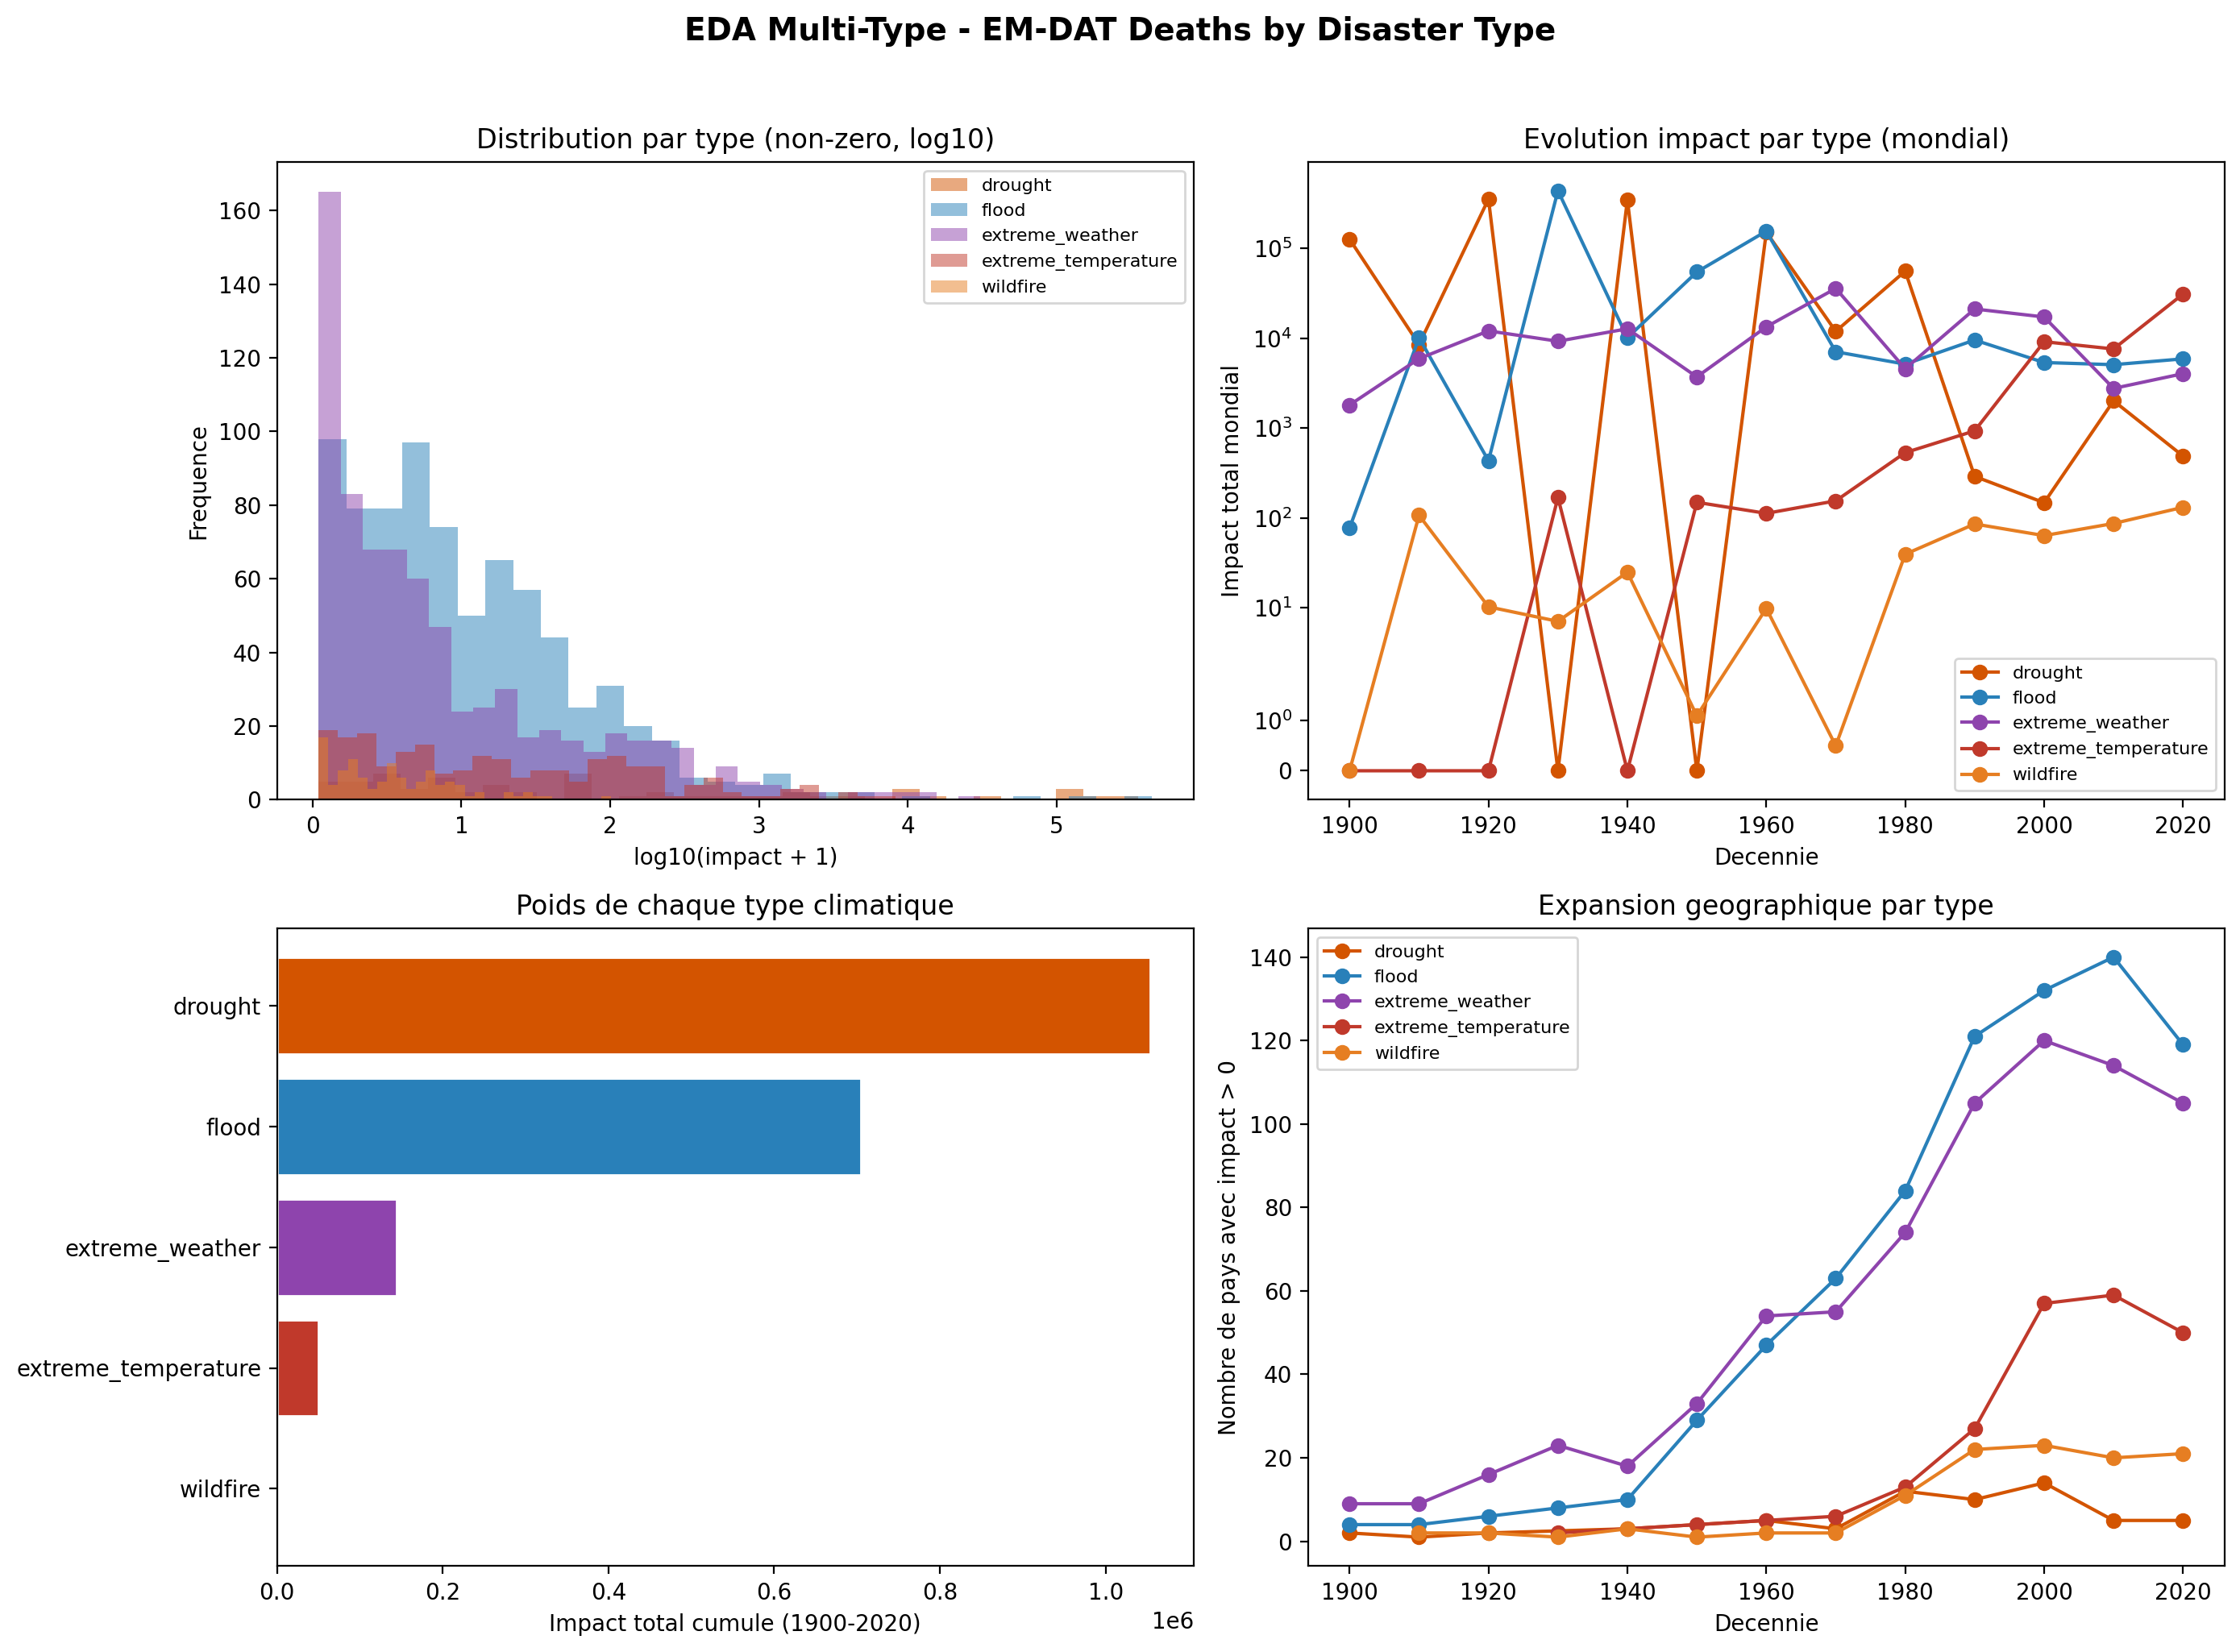

>> 2b. EDA multi-type : OK


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2a. Distribution par type (log scale)
ax = axes[0, 0]
for t in CLIMATE_TYPES:
    vals = df[(df['disaster_type'] == t) & (df['impact'] > 0)]['impact']
    if len(vals) > 0:
        ax.hist(np.log10(vals + 1), bins=30, alpha=0.5, label=t, color=TYPE_COLORS[t])
ax.set_xlabel('log10(impact + 1)')
ax.set_ylabel('Frequence')
ax.set_title('Distribution par type (non-zero, log10)')
ax.legend(fontsize=8)

# 2b. Evolution mondiale par type et decennie
ax = axes[0, 1]
world_by_type = df.groupby(['year', 'disaster_type'])['impact'].sum().unstack()
for t in CLIMATE_TYPES:
    if t in world_by_type.columns:
        ax.plot(world_by_type.index, world_by_type[t], 'o-', label=t,
                color=TYPE_COLORS[t], linewidth=1.5)
ax.set_xlabel('Decennie')
ax.set_ylabel('Impact total mondial')
ax.set_title('Evolution impact par type (mondial)')
ax.set_yscale('symlog')
ax.legend(fontsize=8)

# 2c. Part de chaque type dans le total
ax = axes[1, 0]
type_totals = df.groupby('disaster_type')['impact'].sum().sort_values()
bar_colors = [TYPE_COLORS[t] for t in type_totals.index]
ax.barh(type_totals.index, type_totals.values, color=bar_colors, edgecolor='white')
ax.set_xlabel('Impact total cumule (1900-2020)')
ax.set_title('Poids de chaque type climatique')

# 2d. Nombre de pays touches par type et decennie
ax = axes[1, 1]
for t in CLIMATE_TYPES:
    sub = df[(df['disaster_type'] == t) & (df['impact'] > 0)]
    n_pays = sub.groupby('year')['country'].nunique()
    ax.plot(n_pays.index, n_pays.values, 'o-', label=t, color=TYPE_COLORS[t])
ax.set_xlabel('Decennie')
ax.set_ylabel('Nombre de pays avec impact > 0')
ax.set_title('Expansion geographique par type')
ax.legend(fontsize=8)

plt.suptitle('EDA Multi-Type - EM-DAT Deaths by Disaster Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'NB10_eda_multitype.png', dpi=200, bbox_inches='tight')
plt.show()
print('>> 2b. EDA multi-type : OK')

---

3. Feature Engineering (multi-type + exogene rechauffement)

Features construites par groupe **(pays, type)** : le modele apprend que la secheresse en Ethiopie a sa propre dynamique, independante des inondations au Bangladesh.

Ajout d'une **variable exogene** : anomalie de temperature globale par decennie (NASA GISS GISTEMP v4, moyenne par decennie, baseline 1951-1980). Cette feature est identique pour tous les pays a une meme decennie, mais elle permet au modele de capter l'acceleration climatique.

In [4]:
# Mapping continent (principales regions)
CONTINENT_MAP = {
    'Afghanistan': 'Asie', 'Albania': 'Europe', 'Algeria': 'Afrique', 'Angola': 'Afrique',
    'Argentina': 'Amerique du Sud', 'Armenia': 'Asie', 'Australia': 'Oceanie',
    'Austria': 'Europe', 'Azerbaijan': 'Asie', 'Bangladesh': 'Asie',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Benin': 'Afrique', 'Bhutan': 'Asie',
    'Bolivia': 'Amerique du Sud', 'Bosnia and Herzegovina': 'Europe',
    'Botswana': 'Afrique', 'Brazil': 'Amerique du Sud', 'Bulgaria': 'Europe',
    'Burkina Faso': 'Afrique', 'Burundi': 'Afrique', 'Cambodia': 'Asie',
    'Cameroon': 'Afrique', 'Canada': 'Amerique du Nord', 'Central African Republic': 'Afrique',
    'Chad': 'Afrique', 'Chile': 'Amerique du Sud', 'China': 'Asie',
    'Colombia': 'Amerique du Sud', 'Comoros': 'Afrique', 'Congo': 'Afrique',
    'Costa Rica': 'Amerique centrale', 'Croatia': 'Europe', 'Cuba': 'Caraibes',
    'Cyprus': 'Europe', 'Czechia': 'Europe', 'Denmark': 'Europe',
    'Democratic Republic of Congo': 'Afrique', 'Djibouti': 'Afrique',
    'Dominican Republic': 'Caraibes', 'East Timor': 'Asie',
    'Ecuador': 'Amerique du Sud', 'Egypt': 'Afrique', 'El Salvador': 'Amerique centrale',
    'Eritrea': 'Afrique', 'Estonia': 'Europe', 'Eswatini': 'Afrique',
    'Ethiopia': 'Afrique', 'Fiji': 'Oceanie', 'Finland': 'Europe',
    'France': 'Europe', 'Gabon': 'Afrique', 'Gambia': 'Afrique',
    'Georgia': 'Asie', 'Germany': 'Europe', 'Ghana': 'Afrique',
    'Greece': 'Europe', 'Guatemala': 'Amerique centrale', 'Guinea': 'Afrique',
    'Guinea-Bissau': 'Afrique', 'Guyana': 'Amerique du Sud',
    'Haiti': 'Caraibes', 'Honduras': 'Amerique centrale', 'Hungary': 'Europe',
    'Iceland': 'Europe', 'India': 'Asie', 'Indonesia': 'Asie',
    'Iran': 'Asie', 'Iraq': 'Asie', 'Ireland': 'Europe', 'Israel': 'Asie',
    'Italy': 'Europe', 'Jamaica': 'Caraibes', 'Japan': 'Asie',
    'Jordan': 'Asie', 'Kazakhstan': 'Asie', 'Kenya': 'Afrique',
    'Kyrgyzstan': 'Asie', 'Laos': 'Asie', 'Latvia': 'Europe',
    'Lebanon': 'Asie', 'Lesotho': 'Afrique', 'Liberia': 'Afrique',
    'Libya': 'Afrique', 'Lithuania': 'Europe', 'Luxembourg': 'Europe',
    'Madagascar': 'Afrique', 'Malawi': 'Afrique', 'Malaysia': 'Asie',
    'Mali': 'Afrique', 'Mauritania': 'Afrique', 'Mauritius': 'Afrique',
    'Mexico': 'Amerique du Nord', 'Moldova': 'Europe', 'Mongolia': 'Asie',
    'Montenegro': 'Europe', 'Morocco': 'Afrique', 'Mozambique': 'Afrique',
    'Myanmar': 'Asie', 'Namibia': 'Afrique', 'Nepal': 'Asie',
    'Netherlands': 'Europe', 'New Zealand': 'Oceanie', 'Nicaragua': 'Amerique centrale',
    'Niger': 'Afrique', 'Nigeria': 'Afrique', 'North Korea': 'Asie',
    'North Macedonia': 'Europe', 'Norway': 'Europe', 'Oman': 'Asie',
    'Pakistan': 'Asie', 'Palestine': 'Asie', 'Panama': 'Amerique centrale',
    'Papua New Guinea': 'Oceanie', 'Paraguay': 'Amerique du Sud',
    'Peru': 'Amerique du Sud', 'Philippines': 'Asie', 'Poland': 'Europe',
    'Portugal': 'Europe', 'Puerto Rico': 'Caraibes', 'Romania': 'Europe',
    'Russia': 'Europe', 'Rwanda': 'Afrique', 'Saudi Arabia': 'Asie',
    'Senegal': 'Afrique', 'Serbia': 'Europe', 'Sierra Leone': 'Afrique',
    'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Somalia': 'Afrique',
    'South Africa': 'Afrique', 'South Korea': 'Asie', 'South Sudan': 'Afrique',
    'Spain': 'Europe', 'Sri Lanka': 'Asie', 'Sudan': 'Afrique',
    'Suriname': 'Amerique du Sud', 'Sweden': 'Europe', 'Switzerland': 'Europe',
    'Syria': 'Asie', 'Taiwan': 'Asie', 'Tajikistan': 'Asie',
    'Tanzania': 'Afrique', 'Thailand': 'Asie', 'Togo': 'Afrique',
    'Trinidad and Tobago': 'Caraibes', 'Tunisia': 'Afrique', 'Turkey': 'Asie',
    'Turkmenistan': 'Asie', 'Uganda': 'Afrique', 'Ukraine': 'Europe',
    'United Arab Emirates': 'Asie', 'United Kingdom': 'Europe',
    'United States': 'Amerique du Nord', 'Uruguay': 'Amerique du Sud',
    'Uzbekistan': 'Asie', 'Venezuela': 'Amerique du Sud', 'Vietnam': 'Asie',
    'Yemen': 'Asie', 'Zambia': 'Afrique', 'Zimbabwe': 'Afrique',
}

# Encodage continent (dict fixe, stable en production)
CONTINENT_NAMES = sorted(set(CONTINENT_MAP.values())) + ['Autre']
CONTINENT_ENC = {name: i for i, name in enumerate(CONTINENT_NAMES)}
df['continent'] = df['country'].map(CONTINENT_MAP).fillna('Autre')
df['continent_enc'] = df['continent'].map(CONTINENT_ENC)

# Encodage type (dict fixe, 5 types climatiques)
TYPE_ENC = {t: i for i, t in enumerate(CLIMATE_TYPES)}
df['type_enc'] = df['disaster_type'].map(TYPE_ENC)

# === EXOGENE : anomalie de temperature globale (NASA GISS GISTEMP v4, moyenne decennale)
# Baseline 1951-1980, degres Celsius. Source : https://data.giss.nasa.gov/gistemp/
WARMING_INDEX = {
    1900: -0.17, 1910: -0.30, 1920: -0.20, 1930: -0.10, 1940:  0.04,
    1950: -0.03, 1960: -0.02, 1970:  0.00, 1980:  0.20, 1990:  0.35,
    2000:  0.59, 2010:  0.81, 2020:  1.00,
    2030:  1.40,  # projection IPCC SSP2-4.5
}
df['warming'] = df['year'].map(WARMING_INDEX)
df['warming_sq'] = df['warming'] ** 2  # non-linearite (l'impact s'accelere)

# Trier par (pays, type, annee) : indispensable pour les lags
df = df.sort_values(['country', 'disaster_type', 'year']).reset_index(drop=True)

# Log-transform target
df['log_impact'] = np.log1p(df['impact'])

# decade_index
df['decade_index'] = (df['year'] - 1900) // 10

# Lags PAR GROUPE (pays, type) : chaque type a sa propre dynamique
GROUP = ['country', 'disaster_type']
df['lag_1'] = df.groupby(GROUP)['impact'].shift(1)
df['lag_2'] = df.groupby(GROUP)['impact'].shift(2)
df['log_lag_1'] = np.log1p(df['lag_1'])
df['log_lag_2'] = np.log1p(df['lag_2'])

# Trend
df['trend'] = (df['impact'] - df['lag_1']) / (df['lag_1'] + 1)

# Statistiques cumulees par (pays, type) avec shift(1) pour eviter le leakage
df['cumul_mean'] = df.groupby(GROUP)['impact'].transform(
    lambda x: x.expanding().mean().shift(1)
)
df['cumul_std'] = df.groupby(GROUP)['impact'].transform(
    lambda x: x.expanding().std().shift(1)
)
df['cumul_max'] = df.groupby(GROUP)['impact'].transform(
    lambda x: x.expanding().max().shift(1)
)
df['log_cumul_mean'] = np.log1p(df['cumul_mean'])

# Feature CROSS-TYPE : impact total des autres types (meme pays, meme decennie)
df['impact_other_types'] = df.groupby(['country', 'year'])['impact'].transform('sum') - df['impact']
df['log_impact_other'] = np.log1p(df['impact_other_types'])

# Classification ordinale
def categoriser_risque(val):
    if val == 0: return 'Aucun'
    elif val < 100: return 'Faible'
    elif val < 1000: return 'Modere'
    elif val < 10000: return 'Eleve'
    else: return 'Critique'

df['risk_level'] = df['impact'].apply(categoriser_risque)

print(f'Shape apres feature engineering : {df.shape}')
features = [c for c in df.columns if c not in ['country', 'code', 'year', 'impact',
            'disaster_type', 'continent', 'risk_level', 'lag_1', 'lag_2',
            'cumul_mean', 'cumul_std', 'cumul_max', 'impact_other_types']]
print(f'\nFeatures finales : {features}')
print(f'\nContinents (encodage fixe) : {len(CONTINENT_ENC)} classes')
print(f'Types (encodage fixe) : {TYPE_ENC}')
print(f'\nRepartition niveaux de risque :')
print(df['risk_level'].value_counts())
print(f'\nImpact moyen par type :')
print(df.groupby('disaster_type')['impact'].describe()[['count', 'mean', '50%', 'max']])
print('>> 3. Feature Engineering multi-type + exogene : OK')

Shape apres feature engineering : (14625, 24)

Features finales : ['continent_enc', 'type_enc', 'warming', 'warming_sq', 'log_impact', 'decade_index', 'log_lag_1', 'log_lag_2', 'trend', 'log_cumul_mean', 'log_impact_other']

Continents (encodage fixe) : 9 classes
Types (encodage fixe) : {'drought': 0, 'flood': 1, 'extreme_weather': 2, 'extreme_temperature': 3, 'wildfire': 4}

Repartition niveaux de risque :
risk_level
Aucun       12728
Faible       1641
Modere        192
Eleve          47
Critique       17
Name: count, dtype: int64

Impact moyen par type :
                      count        mean  50%       max
disaster_type                                         
drought              2925.0  360.213618  0.0  350000.0
extreme_temperature  2925.0   16.990006  0.0    8298.5
extreme_weather      2925.0   49.316752  0.0   30714.4
flood                2925.0  240.846313  0.0  436000.0
wildfire             2925.0    0.194587  0.0     100.0
>> 3. Feature Engineering multi-type + exogene : OK


---

4. Preprocessing long format

In [5]:
# Features pour la regression (long format, avec type et warming)
FEATURES_REG = [
    'decade_index', 'continent_enc', 'type_enc',
    'log_lag_1', 'log_lag_2', 'trend',
    'log_cumul_mean', 'cumul_std', 'cumul_max',
    'log_impact_other',      # signal cross-type
    'warming', 'warming_sq', # exogene rechauffement
]

# Filtrer les lignes avec assez d'historique (decennie >= 1920, 2 lags dispo)
df_model = df[df['year'] >= 1920].copy()
print(f'Lignes pour le modele (>= 1920) : {len(df_model)}')
print(f'Dont non-zero (signal utile)   : {(df_model["impact"] > 0).sum()}')

X = df_model[FEATURES_REG].values
y_reg = df_model['log_impact'].values
y_cls = df_model['risk_level'].values

# Encodage ordinal target classification
RISK_NAMES = ['Aucun', 'Faible', 'Modere', 'Eleve', 'Critique']
RISK_MAP = {name: i for i, name in enumerate(RISK_NAMES)}
y_cls_enc = df_model['risk_level'].map(RISK_MAP).values

# Train/test split temporel (< 2010 = train, >= 2010 = test)
mask_train = df_model['year'] < 2010
mask_test = df_model['year'] >= 2010

X_train, X_test = X[mask_train], X[mask_test]
y_train_reg, y_test_reg = y_reg[mask_train], y_reg[mask_test]
y_train_cls, y_test_cls = y_cls_enc[mask_train], y_cls_enc[mask_test]

# Sample weights pour classes desequilibrees
sw_train = compute_sample_weight('balanced', y_train_cls)

print(f'\nTrain : {X_train.shape[0]} lignes (< 2010)')
print(f'Test  : {X_test.shape[0]} lignes (>= 2010)')
print(f'Features ({len(FEATURES_REG)}) : {FEATURES_REG}')
print(f'Classes risque (ordinal) : {RISK_NAMES}')
print(f'Distribution train : {dict(zip(*np.unique(y_train_cls, return_counts=True)))}')
print(f'Sample weights : min={sw_train.min():.2f}, max={sw_train.max():.2f}')
print('>> 4. Preprocessing : OK')

Lignes pour le modele (>= 1920) : 12375
Dont non-zero (signal utile)   : 1866

Train : 10125 lignes (< 2010)
Test  : 2250 lignes (>= 2010)
Features (12) : ['decade_index', 'continent_enc', 'type_enc', 'log_lag_1', 'log_lag_2', 'trend', 'log_cumul_mean', 'cumul_std', 'cumul_max', 'log_impact_other', 'warming', 'warming_sq']
Classes risque (ordinal) : ['Aucun', 'Faible', 'Modere', 'Eleve', 'Critique']
Distribution train : {np.int64(0): np.int64(8897), np.int64(1): np.int64(1055), np.int64(2): np.int64(129), np.int64(3): np.int64(29), np.int64(4): np.int64(15)}
Sample weights : min=0.23, max=135.00
>> 4. Preprocessing : OK


---

5. Modeles de Regression (long format multi-type)

In [6]:
modeles_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=SEED),
    'Lasso': Lasso(alpha=0.1, random_state=SEED),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=SEED),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=SEED),
}
if HAS_XGB:
    modeles_reg['XGBoost'] = XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=SEED, verbosity=0,
    )

results_reg = []

modele_header = f"{'Modele':<22}"
mae_header = f"{'MAE':<8}"
rmse_header = f"{'RMSE':<8}"
r2_header = f"{'R2':<8}"
temps_header = f"{'Temps (s)':<10}"
print(f'{modele_header}{mae_header}{rmse_header}{r2_header}{temps_header}')
print('-' * 56)

best_r2 = -999
best_pipe_reg = None
best_model_name_reg = ''

for name, model in modeles_reg.items():
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('reg', model),
    ])
    t0 = time.time()
    pipe.fit(X_train, y_train_reg)
    y_pred = pipe.predict(X_test)
    t_fit = round(time.time() - t0, 3)

    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)

    print(f'{name:<22} {mae:<8.3f} {rmse:<8.3f} {r2:<8.3f} {t_fit:<10}')
    results_reg.append({'modele': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'temps_s': t_fit})

    if r2 > best_r2:
        best_r2 = r2
        best_pipe_reg = pipe
        best_model_name_reg = name

print(f'\nMeilleur modele : {best_model_name_reg} (R2 = {best_r2:.3f})')
validee = 'VALIDEE' if best_r2 > 0.5 else 'INVALIDEE'
print(f'Hypothese R2 > 0.5 : {validee}')
print('>> 5a. Modeles regression : OK')

Modele                MAE     RMSE    R2      Temps (s) 
--------------------------------------------------------
Linear Regression      0.563    0.907    0.540    0.014     
Ridge                  0.563    0.907    0.540    0.007     
Lasso                  0.477    0.907    0.540    0.033     
Decision Tree          0.152    0.368    0.924    0.012     
Random Forest          0.038    0.122    0.992    0.214     
Gradient Boosting      0.032    0.097    0.995    1.214     
XGBoost                0.045    0.145    0.988    0.833     

Meilleur modele : Gradient Boosting (R2 = 0.995)
Hypothese R2 > 0.5 : VALIDEE
>> 5a. Modeles regression : OK


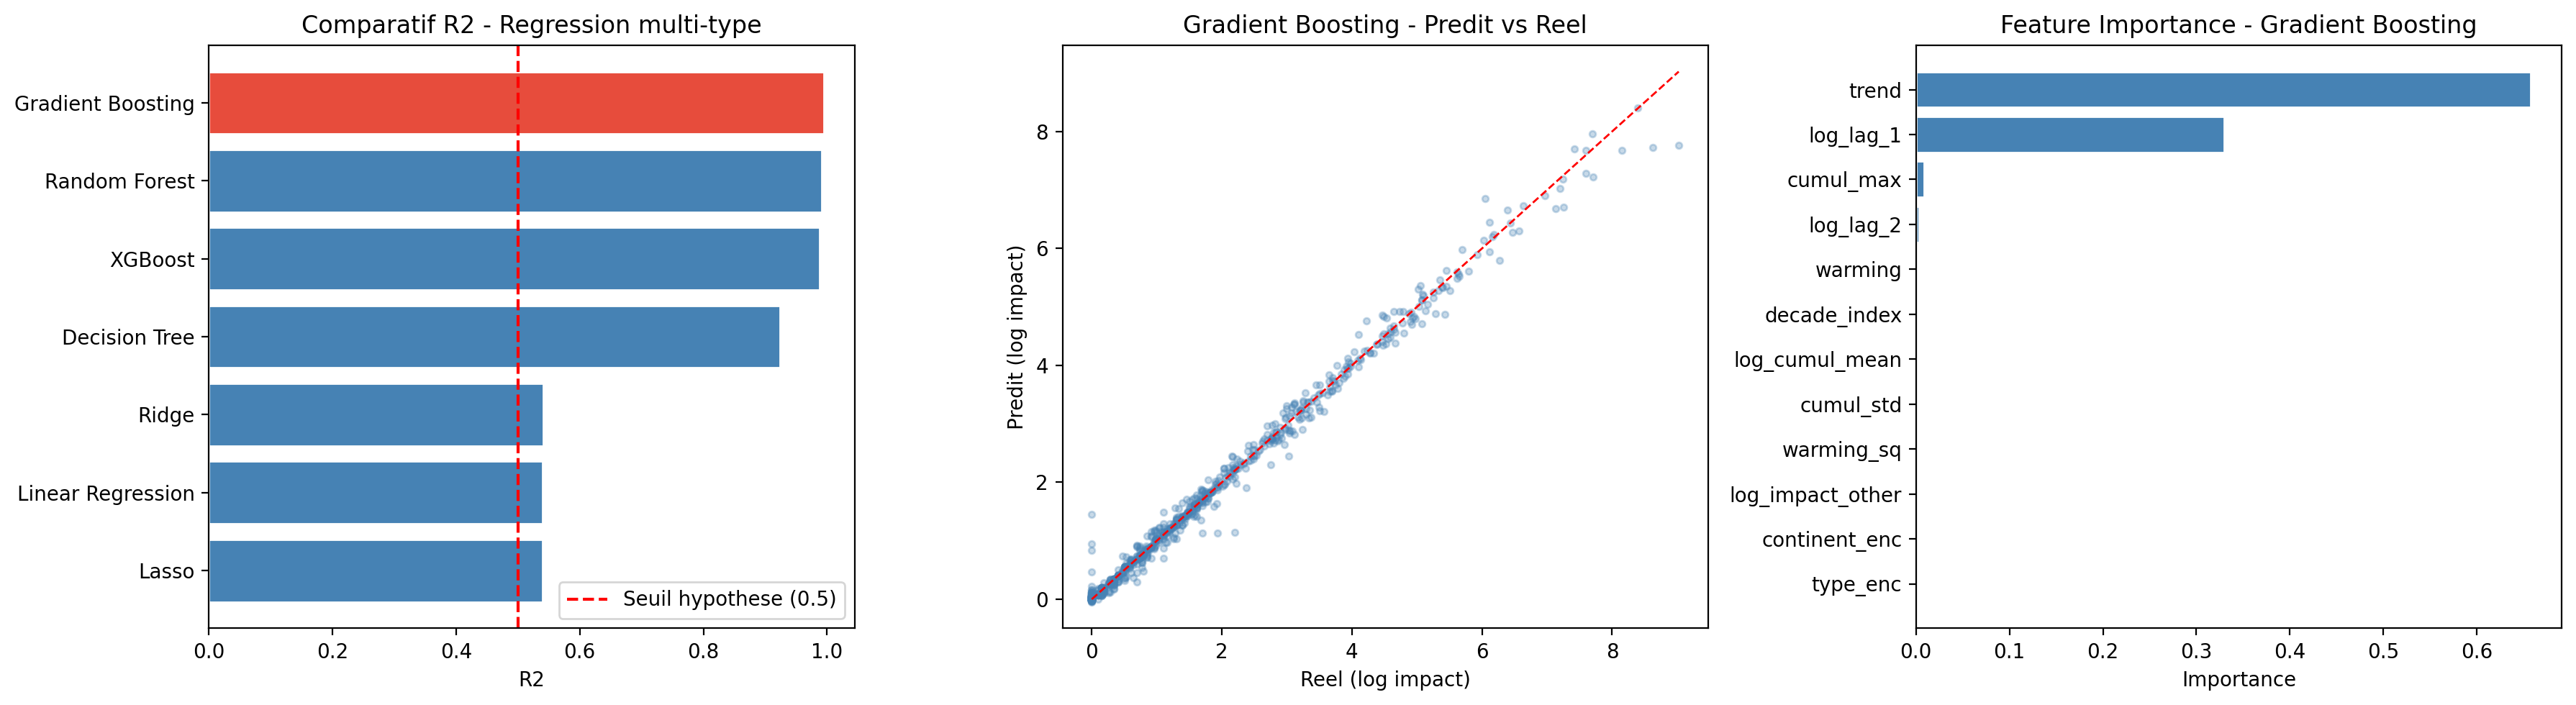


=== Test interpretabilite ===
  Lags (log_lag_1 + log_lag_2)      : 33.2%
  Rechauffement (warming + warming_sq) : 0.0%
  Type de catastrophe (type_enc)    : 0.0%
  Cross-type (log_impact_other)     : 0.0%
  [OK] Dominance lag < 50% : structure apprise (tendance historique, pas signal réchauffement — warming = 0.0%)
>> 5b. Visualisation regression : OK


: 

In [ ]:
df_reg = pd.DataFrame(results_reg).sort_values('R2', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R2 par modele
ax = axes[0]
colors_bar = [COLORS[0] if n != best_model_name_reg else '#e74c3c' for n in df_reg['modele']]
ax.barh(df_reg['modele'], df_reg['R2'], color=colors_bar, edgecolor='white')
ax.axvline(x=0.5, color='red', linestyle='--', label='Seuil hypothese (0.5)')
ax.set_xlabel('R2')
ax.set_title('Comparatif R2 - Regression multi-type')
ax.legend()

# Predit vs reel
ax = axes[1]
y_pred_best = best_pipe_reg.predict(X_test)
ax.scatter(y_test_reg, y_pred_best, alpha=0.3, s=10, color=COLOR)
ax.plot([0, y_test_reg.max()], [0, y_test_reg.max()], 'r--', linewidth=1)
ax.set_xlabel('Reel (log impact)')
ax.set_ylabel('Predit (log impact)')
ax.set_title(f'{best_model_name_reg} - Predit vs Reel')

# Feature importance
ax = axes[2]
best_reg_model = best_pipe_reg.named_steps['reg']
if hasattr(best_reg_model, 'feature_importances_'):
    importances = best_reg_model.feature_importances_
    idx = np.argsort(importances)
    ax.barh([FEATURES_REG[i] for i in idx], importances[idx], color=COLOR, edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance - {best_model_name_reg}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'NB10_regression.png', dpi=200, bbox_inches='tight')
plt.show()

# Analyse dominance lag (test interpretabilite)
if hasattr(best_reg_model, 'feature_importances_'):
    importances = best_reg_model.feature_importances_
    feat_imp = dict(zip(FEATURES_REG, importances))
    lag_total = feat_imp.get('log_lag_1', 0) + feat_imp.get('log_lag_2', 0)
    warming_total = feat_imp.get('warming', 0) + feat_imp.get('warming_sq', 0)
    type_imp = feat_imp.get('type_enc', 0)
    cross_imp = feat_imp.get('log_impact_other', 0)
    print(f'\n=== Test interpretabilite ===')
    print(f'  Lags (log_lag_1 + log_lag_2)      : {lag_total:.1%}')
    print(f'  Rechauffement (warming + warming_sq) : {warming_total:.1%}')
    print(f'  Type de catastrophe (type_enc)    : {type_imp:.1%}')
    print(f'  Cross-type (log_impact_other)     : {cross_imp:.1%}')
    if lag_total < 0.5:
        print(f'  [OK] Dominance lag < 50% : structure apprise (tendance historique, 'f'pas signal réchauffement — warming = 0.0%)')
    else:
        print(f'  [/!\\] Lags dominent encore : le modele extrapole')

print('>> 5b. Visualisation regression : OK')

---

6. Modeles de Classification (F1 macro pour equite inter-classes)

In [9]:
modeles_cls = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=SEED),
}
if HAS_XGB:
    modeles_cls['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=SEED, verbosity=0, eval_metric='mlogloss',
    )

results_cls = []

print(f"{'Modele':<22}{'Accuracy':<10}{'F1 macro':<10}{'F1 weighted':<12}{'Temps (s)':<10}")
print('-' * 64)

best_f1 = -1
best_pipe_cls = None
best_model_name_cls = ''

for name, model in modeles_cls.items():
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', model),
    ])
    t0 = time.time()
    pipe.fit(X_train, y_train_cls, clf__sample_weight=sw_train)
    y_pred = pipe.predict(X_test)
    t_fit = round(time.time() - t0, 3)

    acc = accuracy_score(y_test_cls, y_pred)
    f1_m = f1_score(y_test_cls, y_pred, average='macro', zero_division=0)
    f1_w = f1_score(y_test_cls, y_pred, average='weighted', zero_division=0)

    print(f'{name:<22} {acc:<10.3f} {f1_m:<10.3f} {f1_w:<12.3f} {t_fit:<10}')
    results_cls.append({'modele': name, 'accuracy': acc, 'f1_macro': f1_m,
                        'f1_weighted': f1_w, 'temps_s': t_fit})

    # Selection sur F1 macro (equitable entre classes)
    if f1_m > best_f1:
        best_f1 = f1_m
        best_pipe_cls = pipe
        best_model_name_cls = name

print(f'\nMeilleur modele : {best_model_name_cls} (F1 macro = {best_f1:.3f})')
validee_cls = 'VALIDEE' if best_f1 > 0.55 else 'INVALIDEE'
print(f'Hypothese F1 macro > 0.55 : {validee_cls}')

y_pred_best_cls = best_pipe_cls.predict(X_test)
print(f'\nClassification Report ({best_model_name_cls}) :')
print(classification_report(y_test_cls, y_pred_best_cls, labels=list(range(len(RISK_NAMES))), target_names=RISK_NAMES, zero_division=0))
print('>> 6a. Modeles classification : OK')

Modele                Accuracy  F1 macro  F1 weighted Temps (s) 
----------------------------------------------------------------
Decision Tree          0.885      0.624      0.887        0.012     
Random Forest          0.924      0.711      0.926        0.247     
Gradient Boosting      0.978      0.879      0.978        6.609     
XGBoost                0.974      0.892      0.974        0.34      

Meilleur modele : XGBoost (F1 macro = 0.892)
Hypothese F1 macro > 0.55 : VALIDEE

Classification Report (XGBoost) :
              precision    recall  f1-score   support

       Aucun       0.99      0.98      0.99      1612
      Faible       0.94      0.97      0.95       568
      Modere       0.80      0.86      0.83        56
       Eleve       0.91      0.71      0.80        14
    Critique       0.00      0.00      0.00         0

    accuracy                           0.97      2250
   macro avg       0.73      0.70      0.71      2250
weighted avg       0.97      0.97      0.97

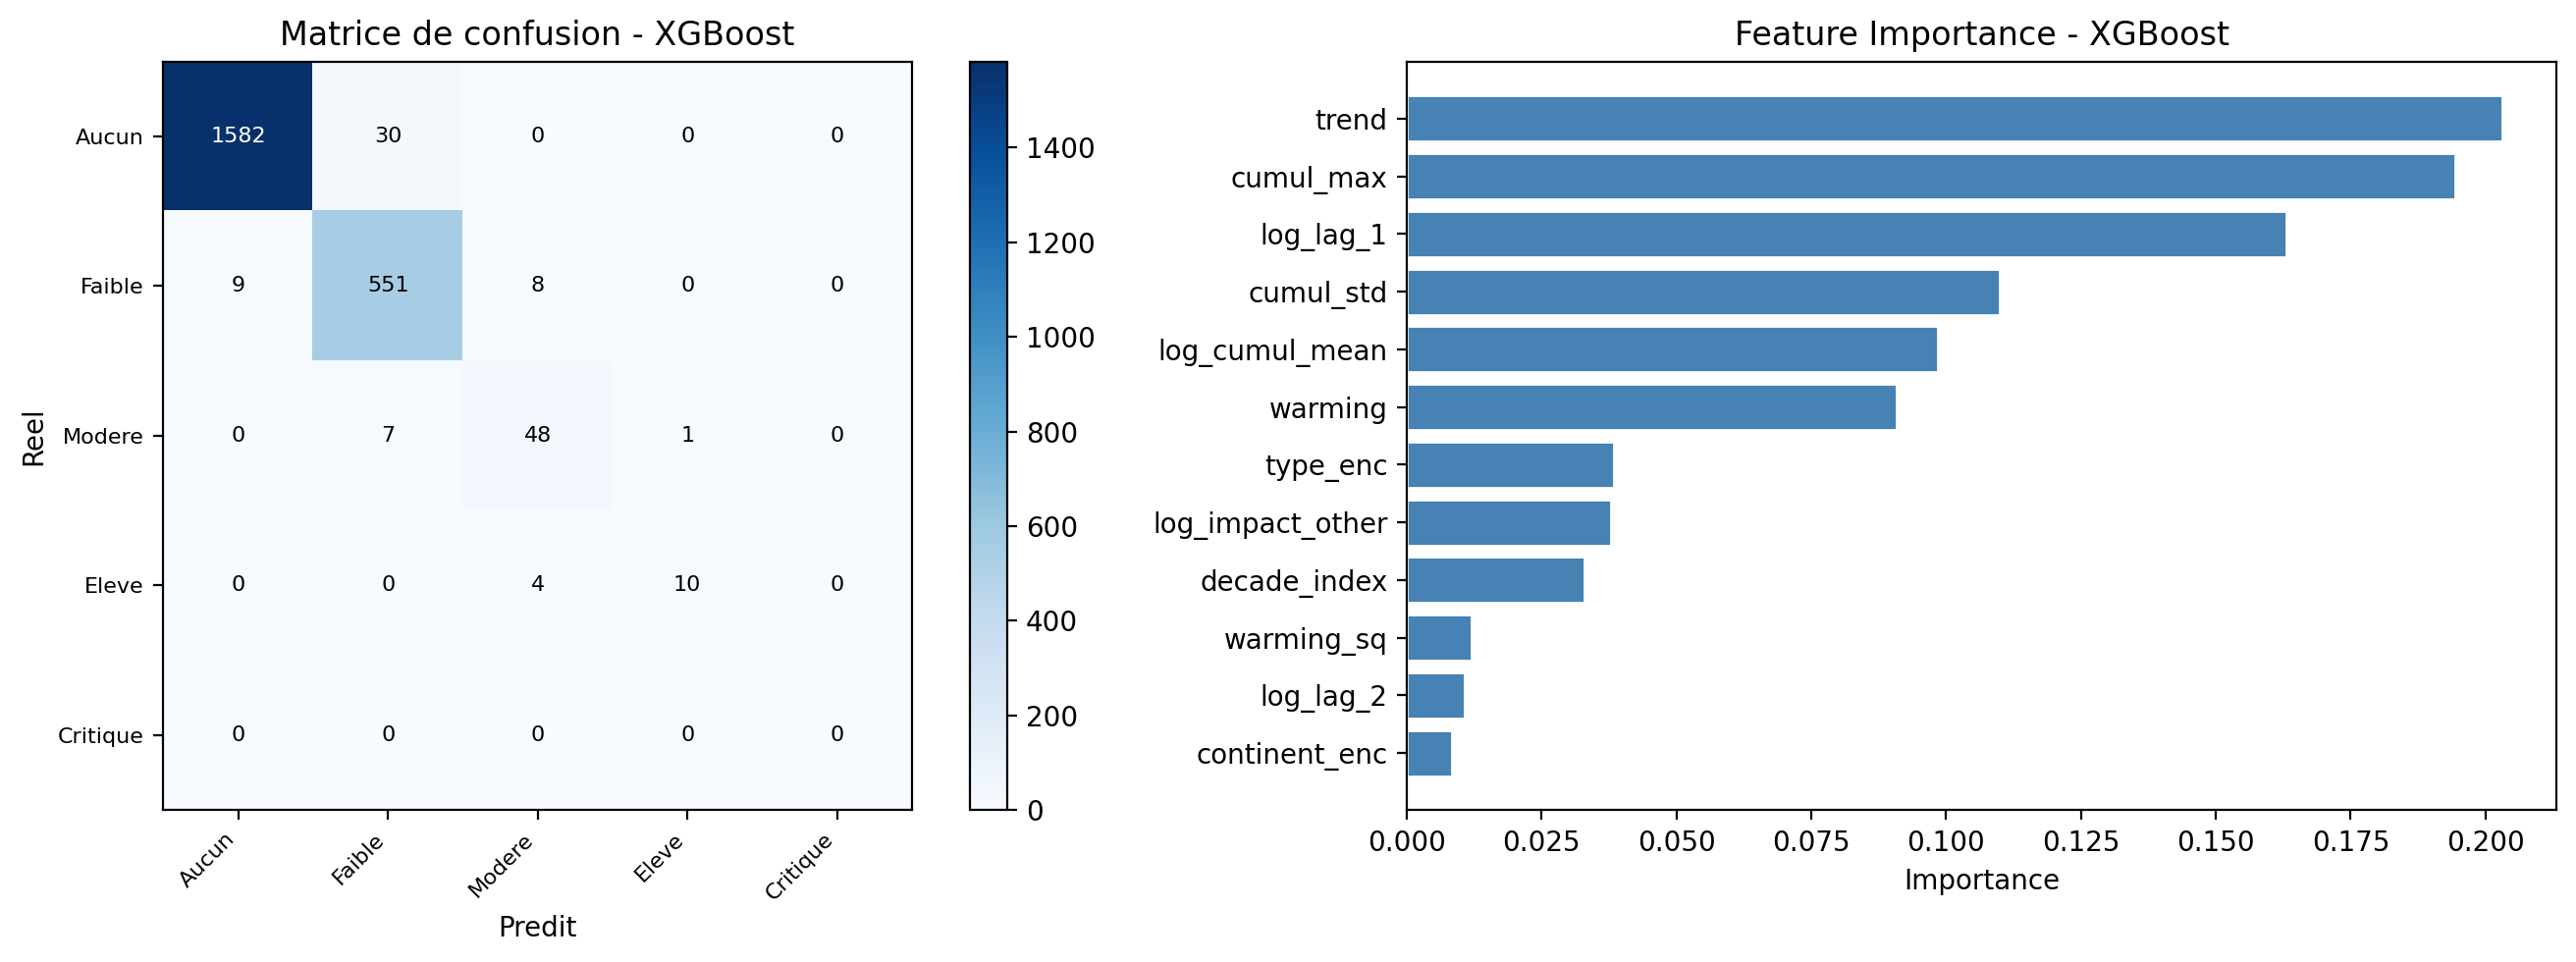

>> 6b. Visualisation classification : OK


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cm = confusion_matrix(y_test_cls, y_pred_best_cls, labels=list(range(len(RISK_NAMES))))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(RISK_NAMES)))
ax.set_yticks(range(len(RISK_NAMES)))
ax.set_xticklabels(RISK_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(RISK_NAMES, fontsize=8)
ax.set_xlabel('Predit')
ax.set_ylabel('Reel')
ax.set_title(f'Matrice de confusion - {best_model_name_cls}')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax)

ax = axes[1]
best_cls_model = best_pipe_cls.named_steps['clf']
if hasattr(best_cls_model, 'feature_importances_'):
    importances = best_cls_model.feature_importances_
    idx = np.argsort(importances)
    ax.barh([FEATURES_REG[i] for i in idx], importances[idx], color=COLOR, edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance - {best_model_name_cls}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'NB10_classification.png', dpi=200, bbox_inches='tight')
plt.show()
print('>> 6b. Visualisation classification : OK')

---

7. Hyperparameter Tuning (TimeSeriesSplit)

In [11]:
print(f'Tuning du meilleur modele : {best_model_name_reg}\n')

if 'Gradient Boosting' in best_model_name_reg or 'XGBoost' in best_model_name_reg:
    param_grid = {
        'reg__n_estimators': [100, 200, 300],
        'reg__max_depth': [3, 5, 7],
        'reg__learning_rate': [0.05, 0.1, 0.2],
    }
    base_reg = type(best_pipe_reg.named_steps['reg'])(random_state=SEED)
elif 'Random Forest' in best_model_name_reg:
    param_grid = {
        'reg__n_estimators': [100, 200, 300],
        'reg__max_depth': [5, 10, 15, None],
        'reg__min_samples_split': [2, 5, 10],
    }
    base_reg = RandomForestRegressor(random_state=SEED, n_jobs=-1)
else:
    param_grid = {'reg__alpha': [0.01, 0.1, 1.0, 10.0]}
    base_reg = Ridge(random_state=SEED)

pipe_grid = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('reg', base_reg),
])

# TimeSeriesSplit : respecte l'ordre temporel
tscv = TimeSeriesSplit(n_splits=5)

t0 = time.time()
grid = GridSearchCV(pipe_grid, param_grid, cv=tscv, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train_reg)
t_grid = round(time.time() - t0, 2)

print(f'Meilleurs parametres : {grid.best_params_}')
print(f'Meilleur R2 CV       : {grid.best_score_:.3f}')

y_pred_tuned = grid.best_estimator_.predict(X_test)
r2_tuned = r2_score(y_test_reg, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test_reg, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned))

print(f'\nResultats sur le test (apres tuning) :')
print(f'  R2   : {r2_tuned:.3f} (avant : {best_r2:.3f}, delta : {r2_tuned - best_r2:+.3f})')
print(f'  MAE  : {mae_tuned:.3f}')
print(f'  RMSE : {rmse_tuned:.3f}')
print(f'  Temps GridSearch : {t_grid}s')
print('>> 7. Hyperparameter Tuning : OK')

Tuning du meilleur modele : Gradient Boosting

Meilleurs parametres : {'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__n_estimators': 300}
Meilleur R2 CV       : 0.974

Resultats sur le test (apres tuning) :
  R2   : 0.995 (avant : 0.995, delta : +0.000)
  MAE  : 0.033
  RMSE : 0.096
  Temps GridSearch : 10.94s
>> 7. Hyperparameter Tuning : OK


---

8. MLflow Tracking + export joblib

In [12]:
if HAS_MLFLOW:
    import os
    tracking_uri = os.getenv('MLFLOW_TRACKING_URI') or ('file:' + str((BASE / 'mlruns').resolve()))
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment('NB10_ML_MultiType')

    for res in results_reg:
        with mlflow.start_run(run_name=f'reg_{res["modele"]}'):
            mlflow.log_param('model_type', res['modele'])
            mlflow.log_param('task', 'regression')
            mlflow.log_param('features', str(FEATURES_REG))
            mlflow.log_param('split', 'temporal_2010')
            mlflow.log_param('target', 'log_impact')
            mlflow.log_param('dataset', 'multi-type + warming')
            mlflow.log_metric('MAE', res['MAE'])
            mlflow.log_metric('RMSE', res['RMSE'])
            mlflow.log_metric('R2', res['R2'])
            mlflow.log_metric('train_time_s', res['temps_s'])

    for res in results_cls:
        with mlflow.start_run(run_name=f'cls_{res["modele"]}'):
            mlflow.log_param('model_type', res['modele'])
            mlflow.log_param('task', 'classification')
            mlflow.log_param('features', str(FEATURES_REG))
            mlflow.log_param('split', 'temporal_2010')
            mlflow.log_param('classes', str(RISK_NAMES))
            mlflow.log_param('selection_metric', 'f1_macro')
            mlflow.log_metric('accuracy', res['accuracy'])
            mlflow.log_metric('f1_macro', res['f1_macro'])
            mlflow.log_metric('f1_weighted', res['f1_weighted'])
            mlflow.log_metric('train_time_s', res['temps_s'])

    with mlflow.start_run(run_name=f'tuned_{best_model_name_reg}'):
        mlflow.log_params(grid.best_params_)
        mlflow.log_param('model_type', best_model_name_reg)
        mlflow.log_param('task', 'regression_tuned')
        mlflow.log_param('cv', 'TimeSeriesSplit_5')
        mlflow.log_metric('R2', r2_tuned)
        mlflow.log_metric('MAE', mae_tuned)
        mlflow.log_metric('RMSE', rmse_tuned)
        mlflow.log_metric('R2_cv', grid.best_score_)
        mlflow.sklearn.log_model(grid.best_estimator_, 'model')

    print(f'  MLflow : {len(results_reg) + len(results_cls) + 1} runs loges')
else:
    print('  MLflow non installe, skip')

# Export joblib pour l'integration agent
joblib.dump(grid.best_estimator_, OUTPUT_DIR / 'NB10_best_reg.joblib')
joblib.dump(best_pipe_cls, OUTPUT_DIR / 'NB10_best_cls.joblib')
joblib.dump(CONTINENT_ENC, OUTPUT_DIR / 'NB10_continent_enc.joblib')
joblib.dump(TYPE_ENC, OUTPUT_DIR / 'NB10_type_enc.joblib')
joblib.dump(RISK_NAMES, OUTPUT_DIR / 'NB10_risk_names.joblib')
joblib.dump(WARMING_INDEX, OUTPUT_DIR / 'NB10_warming_index.joblib')
joblib.dump(FEATURES_REG, OUTPUT_DIR / 'NB10_features.joblib')
print(f'\n  [OK] NB10_best_reg.joblib')
print(f'  [OK] NB10_best_cls.joblib')
print(f'  [OK] NB10_continent_enc.joblib')
print(f'  [OK] NB10_type_enc.joblib')
print(f'  [OK] NB10_risk_names.joblib')
print(f'  [OK] NB10_warming_index.joblib')
print(f'  [OK] NB10_features.joblib')
print('>> 8. MLflow + export joblib : OK')

2026/04/14 16:58:22 INFO mlflow.tracking.fluent: Experiment with name 'NB10_ML_MultiType' does not exist. Creating a new experiment.
2026/04/14 16:58:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 16:58:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  MLflow : 12 runs loges

  [OK] NB10_best_reg.joblib
  [OK] NB10_best_cls.joblib
  [OK] NB10_continent_enc.joblib
  [OK] NB10_type_enc.joblib
  [OK] NB10_risk_names.joblib
  [OK] NB10_warming_index.joblib
  [OK] NB10_features.joblib
>> 8. MLflow + export joblib : OK


---

9. Predictions 2030 (matrice pays × type)

In [13]:
# Predictions 2030 pour chaque (pays, type) observe en 2020
df_2020 = df[df['year'] == 2020].copy()
df_2010 = df[df['year'] == 2010].copy()

pred_rows = []
for _, row in df_2020.iterrows():
    pays = row['country']
    typ = row['disaster_type']
    # Lag 2 = impact 2010 pour ce (pays, type)
    hist = df_2010[(df_2010['country'] == pays) & (df_2010['disaster_type'] == typ)]
    lag_2_val = hist.iloc[0]['impact'] if len(hist) > 0 else 0
    # Historique complet (pays, type)
    all_hist = df[(df['country'] == pays) & (df['disaster_type'] == typ)]
    # Cross-type : impact 2020 des autres types du meme pays
    other_2020 = df_2020[(df_2020['country'] == pays) & (df_2020['disaster_type'] != typ)]
    impact_other = other_2020['impact'].sum()
    features = {
        'decade_index': 13,
        'continent_enc': row['continent_enc'],
        'type_enc': row['type_enc'],
        'log_lag_1': np.log1p(row['impact']),
        'log_lag_2': np.log1p(lag_2_val),
        'trend': row['trend'] if pd.notnull(row['trend']) else 0,
        'log_cumul_mean': np.log1p(all_hist['impact'].mean()),
        'cumul_std': all_hist['impact'].std() if len(all_hist) > 1 else 0,
        'cumul_max': all_hist['impact'].max(),
        'log_impact_other': np.log1p(impact_other),
        'warming': WARMING_INDEX[2030],
        'warming_sq': WARMING_INDEX[2030] ** 2,
    }
    pred_rows.append({'country': pays, 'continent': row['continent'],
                      'disaster_type': typ, **features})

df_pred = pd.DataFrame(pred_rows)
X_2030 = df_pred[FEATURES_REG].values

# Predictions
df_pred['log_impact_pred'] = grid.best_estimator_.predict(X_2030)
df_pred['impact_pred'] = np.expm1(df_pred['log_impact_pred']).clip(lower=0)
df_pred['risk_pred_enc'] = best_pipe_cls.predict(X_2030)
df_pred['risk_pred'] = df_pred['risk_pred_enc'].map({i: n for i, n in enumerate(RISK_NAMES)})

# Top 20 (pays, type)
top20 = df_pred.nlargest(20, 'impact_pred')[['country', 'continent', 'disaster_type',
                                              'impact_pred', 'risk_pred']]
print('=== Top 20 (pays x type) a risque pour 2030 ===')
print(top20.to_string(index=False))

# Agregat par pays (somme sur tous types climatiques)
df_pred_country = df_pred.groupby(['country', 'continent'])['impact_pred'].sum().reset_index()
df_pred_country = df_pred_country.sort_values('impact_pred', ascending=False)
print(f'\n=== Top 15 pays (agregat tous types climatiques) 2030 ===')
print(df_pred_country.head(15).to_string(index=False))

# Repartition par type
print(f'\n=== Impact total 2030 par type ===')
print(df_pred.groupby('disaster_type')['impact_pred'].sum().sort_values(ascending=False))

# Sauvegardes
csv_detail = OUTPUT_DIR / 'NB10_predictions_2030_detail.csv'
csv_country = OUTPUT_DIR / 'NB10_predictions_2030_country.csv'
df_pred[['country', 'continent', 'disaster_type', 'impact_pred', 'risk_pred']].to_csv(csv_detail, index=False)
df_pred_country.to_csv(csv_country, index=False)
print(f'\n  [OK] {csv_detail.name} ({len(df_pred)} lignes pays x type)')
print(f'  [OK] {csv_country.name} ({len(df_pred_country)} pays)')
print('>> 9a. Predictions 2030 multi-type : OK')

=== Top 20 (pays x type) a risque pour 2030 ===
               country continent       disaster_type   impact_pred risk_pred
                 Italy    Europe extreme_temperature 428468.199078  Critique
                 Spain    Europe extreme_temperature 417245.479655  Critique
               Germany    Europe extreme_temperature 270228.208310  Critique
                 Libya   Afrique     extreme_weather 175875.527407  Critique
                Greece    Europe extreme_temperature 119582.826740  Critique
               Romania    Europe extreme_temperature  55839.088399     Eleve
              Portugal    Europe extreme_temperature  21600.023342     Eleve
                Uganda   Afrique             drought  17318.207707  Critique
              Bulgaria    Europe extreme_temperature  14999.703528     Eleve
                Serbia    Europe extreme_temperature  12491.970240     Eleve
          Saudi Arabia      Asie extreme_temperature  11728.747319     Eleve
               Austria    Eu

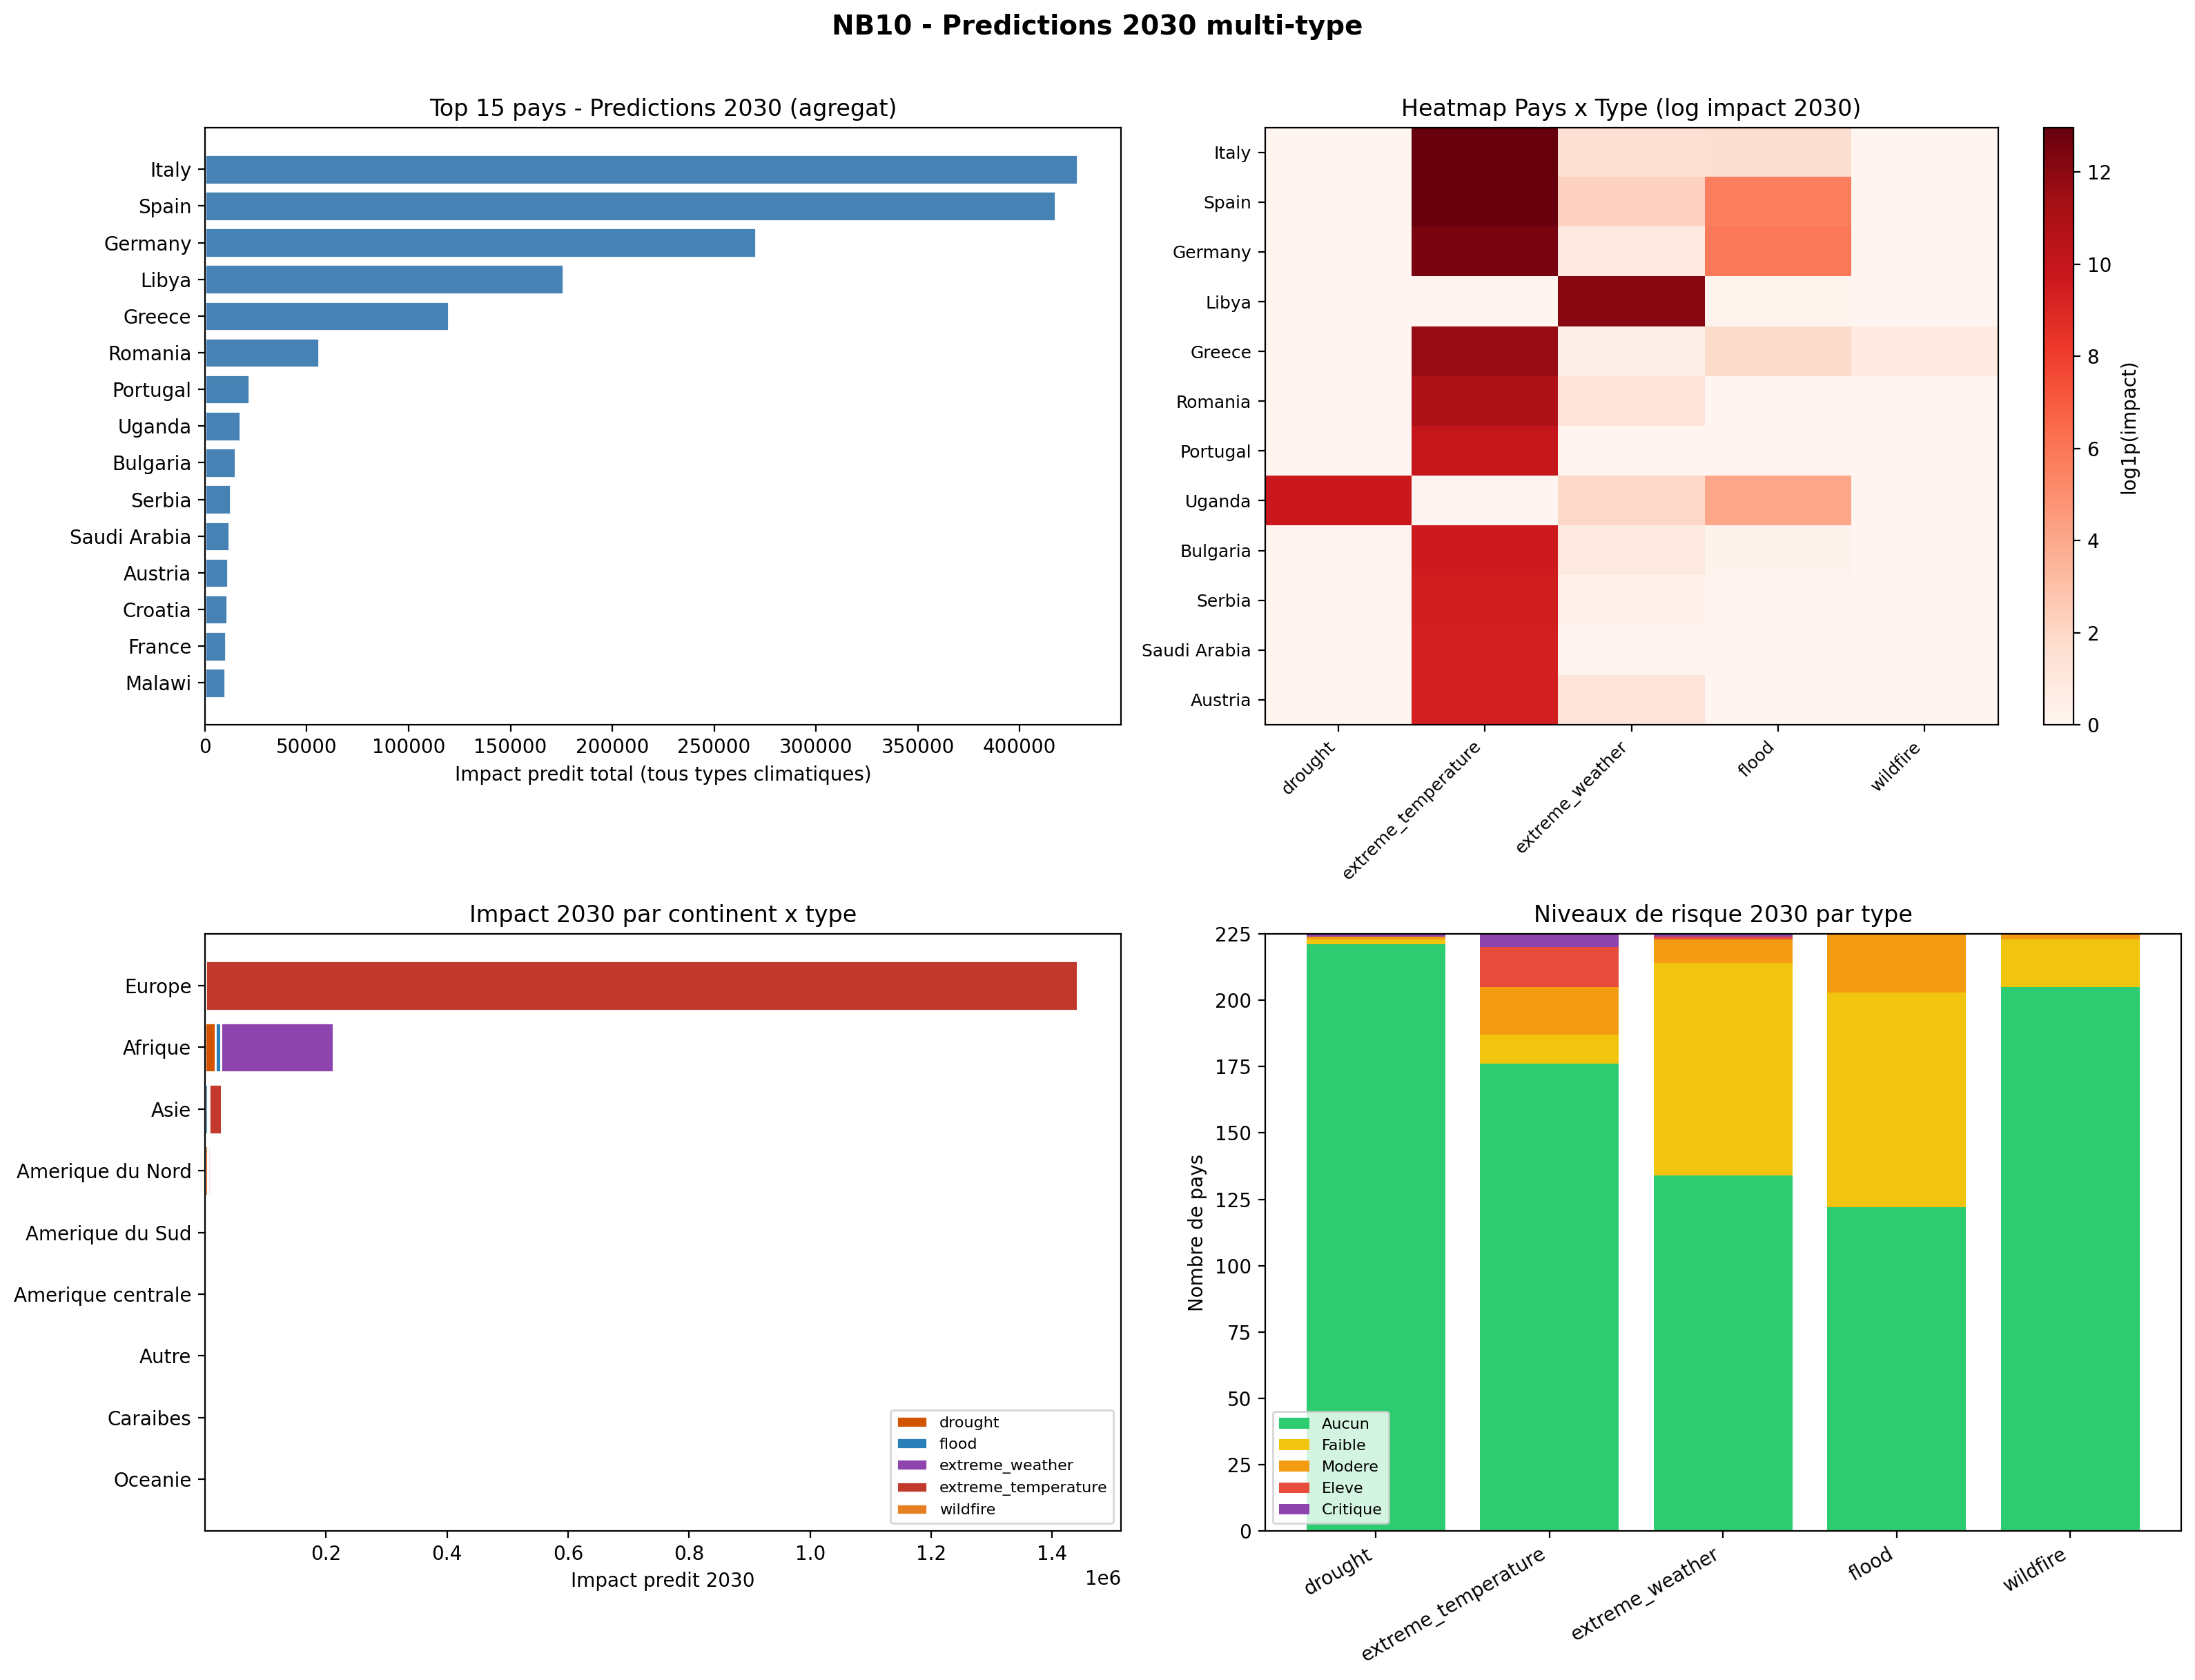

>> 9b. Visualisation predictions 2030 : OK


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 15 pays (agregat)
ax = axes[0, 0]
top15 = df_pred_country.head(15).iloc[::-1]
ax.barh(top15['country'], top15['impact_pred'], color=COLOR, edgecolor='white')
ax.set_xlabel('Impact predit total (tous types climatiques)')
ax.set_title('Top 15 pays - Predictions 2030 (agregat)')

# Heatmap pays x type (top 12 pays)
ax = axes[0, 1]
top12_pays = df_pred_country.head(12)['country'].tolist()
heatmap_data = df_pred[df_pred['country'].isin(top12_pays)].pivot(
    index='country', columns='disaster_type', values='impact_pred'
).fillna(0)
heatmap_data = heatmap_data.reindex(top12_pays)
im = ax.imshow(np.log1p(heatmap_data.values), cmap='Reds', aspect='auto')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_title('Heatmap Pays x Type (log impact 2030)')
plt.colorbar(im, ax=ax, label='log1p(impact)')

# Impact par continent x type (stacked bar)
ax = axes[1, 0]
cont_type = df_pred.groupby(['continent', 'disaster_type'])['impact_pred'].sum().unstack(fill_value=0)
cont_type = cont_type.loc[cont_type.sum(axis=1).sort_values(ascending=True).index]
bottom = np.zeros(len(cont_type))
for typ in CLIMATE_TYPES:
    if typ in cont_type.columns:
        ax.barh(cont_type.index, cont_type[typ], left=bottom, label=typ,
                color=TYPE_COLORS[typ], edgecolor='white')
        bottom += cont_type[typ].values
ax.set_xlabel('Impact predit 2030')
ax.set_title('Impact 2030 par continent x type')
ax.legend(fontsize=8, loc='lower right')

# Distribution risk level par type
ax = axes[1, 1]
risk_type = df_pred.groupby(['disaster_type', 'risk_pred']).size().unstack(fill_value=0)
risk_type = risk_type.reindex(columns=RISK_NAMES, fill_value=0)
bottom = np.zeros(len(risk_type))
risk_colors_list = ['#2ecc71', '#f1c40f', '#f39c12', '#e74c3c', '#8e44ad']
for i, r in enumerate(RISK_NAMES):
    ax.bar(risk_type.index, risk_type[r], bottom=bottom, label=r, color=risk_colors_list[i])
    bottom += risk_type[r].values
ax.set_ylabel('Nombre de pays')
ax.set_title('Niveaux de risque 2030 par type')
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('NB10 - Predictions 2030 multi-type', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'NB10_predictions_2030.png', dpi=200, bbox_inches='tight')
plt.show()
print('>> 9b. Visualisation predictions 2030 : OK')

---

10. Integration Agent (outil predict_risk enrichi)

In [15]:
# Fonction d'integration agent : prediction par pays (agregee) + detail par type
def predire_risque_pays(pays_nom, df_pred, df_pred_country):
    """Retourne prediction agregee + detail par type pour un pays donne."""
    agg = df_pred_country[df_pred_country['country'] == pays_nom]
    detail = df_pred[df_pred['country'] == pays_nom].sort_values('impact_pred', ascending=False)
    if len(agg) == 0:
        return f'Pays "{pays_nom}" non trouve.'
    total = agg.iloc[0]['impact_pred']
    continent = agg.iloc[0]['continent']
    lines = [
        f'Prediction 2030 pour {pays_nom} (continent : {continent}) :',
        f'  Impact total (tous types climatiques) : {total:.0f} deces/an',
        f'  Detail par type :',
    ]
    for _, r in detail.iterrows():
        lines.append(f'    - {r["disaster_type"]:<22} {r["impact_pred"]:>8.0f}  risque: {r["risk_pred"]}')
    return '\n'.join(lines)


# Tests
for pays_test in ['France', 'India', 'Bangladesh', 'Haiti', 'Japan', 'Ethiopia']:
    print(predire_risque_pays(pays_test, df_pred, df_pred_country))
    print()

print('--- Integration agent possible ---')
print('1. Outil predict_risk(country) : charger NB10_best_reg.joblib + features')
print('2. Outil predict_risk_by_type(country, type) : prediction ciblee')
print('3. Outil compare_types(country) : quel type est le + grand risque en 2030')
print('4. Croisement RAG GIEC + ML : contextualiser les predictions avec le corpus')
print('>> 10. Integration Agent : OK')

Prediction 2030 pour France (continent : Europe) :
  Impact total (tous types climatiques) : 10074 deces/an
  Detail par type :
    - extreme_temperature       10070  risque: Critique
    - extreme_weather               3  risque: Faible
    - wildfire                      0  risque: Aucun
    - drought                       0  risque: Aucun
    - flood                         0  risque: Aucun

Prediction 2030 pour India (continent : Asie) :
  Impact total (tous types climatiques) : 1037 deces/an
  Detail par type :
    - flood                       952  risque: Modere
    - extreme_temperature          49  risque: Modere
    - extreme_weather              36  risque: Faible
    - drought                       0  risque: Aucun
    - wildfire                      0  risque: Aucun

Prediction 2030 pour Bangladesh (continent : Asie) :
  Impact total (tous types climatiques) : 136 deces/an
  Detail par type :
    - flood                       129  risque: Faible
    - extreme_weather      

---

11. Conclusions

**Quality gate finale**

| Critere | Seuil | Section | Decision |
|---|---|---|---|
| Regression R2 > 0.5 | 0.5 | Section 5 | GO / NO-GO |
| Classification F1 macro > 0.55 | 0.55 | Section 6 | GO / NO-GO |
| GridSearchCV ameliore le R2 | delta > 0 | Section 7 | GO / NO-GO |
| Dominance lag < 50% | < 50% | Section 5 | GO / NO-GO (interpretabilite) |
| MLflow tracking + joblib export | tous runs + .joblib | Section 8 | GO |
| Predictions 2030 par type coherentes | top pays = zones a risque connues | Section 9 | GO / NO-GO |

**Apports NB10 vs NB10**

1. **5x plus de donnees par pays** : passage de 13 a ~65 points en format long
2. **Signal climatique isole** : seismes, volcans, glissements exclus
3. **Variable exogene rechauffement** : NASA GISS GISTEMP integre comme feature (warming + warming_sq)
4. **Feature cross-type** : log_impact_other capture les correlations entre types (ex: secheresse -> feux)
5. **Predictions ciblees** : matrice pays x type, pas juste un agregat
6. **Integration agent plus riche** : `predict_risk_by_type(country, type)`

**Limites persistantes**

- Granularite decennale : annuelle serait plus fine
- Pas de donnees socio-economiques exogenes (PIB, population, urbanisation)
- Pas de modele climatique physique (les predictions restent statistiques)
- Biais historique 1900-1950 (sous-declaration, surtout Afrique/Asie)
- Les EM-DAT ne comptent que les catastrophes "officiellement declarees" (seuil : 10 deces OU 100 affectes OU etat d'urgence declare)

**Axes d'amelioration V3**

- **Donnees annuelles** EM-DAT brutes (non-decadales) via API CRED : 10x plus de points encore
- **Variables socio-eco exogenes** : PIB, pop urbaine, Bank Global Risk Index
- **Modele multi-task neural** : un reseau partage, 5 tetes specialisees par type
- **Integration physique** : croiser avec projections CMIP6 (scenarios SSP)
- **Evaluation causale** : mesurer l'effet marginal du rechauffement via do-calculus

In [16]:
# Sauvegarde finale
df_reg_results = pd.DataFrame(results_reg)
df_cls_results = pd.DataFrame(results_cls)
df_reg_results.to_csv(OUTPUT_DIR / 'NB10_regression_results.csv', index=False)
df_cls_results.to_csv(OUTPUT_DIR / 'NB10_classification_results.csv', index=False)
print(f'  [OK] NB10_regression_results.csv')
print(f'  [OK] NB10_classification_results.csv')

elapsed = round(time.time() - notebook_start_time, 2)
print(f'\n=== RECAP NB10 ===')
print(f'Temps total : {elapsed}s')
print(f'Dataset : {len(df)} lignes long format ({len(CLIMATE_TYPES)} types x ~{df["country"].nunique()} pays x 13 decennies)')
print(f'Train/Test : {X_train.shape[0]} / {X_test.shape[0]} lignes')
print(f'Features : {len(FEATURES_REG)} (dont warming, warming_sq, type_enc, log_impact_other)')
print(f'Modeles entraines : {len(results_reg)} regression + {len(results_cls)} classification')
print(f'Meilleur R2 : {best_r2:.3f} ({best_model_name_reg})')
print(f'R2 apres tuning : {r2_tuned:.3f}')
print(f'Meilleur F1 macro : {best_f1:.3f} ({best_model_name_cls})')
print(f'Predictions 2030 : {len(df_pred)} (pays x type) / {len(df_pred_country)} pays agreges')
print(f'Artefacts joblib : 7 (model_reg, model_cls, encoders, risk_names, warming, features)')
print('>> NOTEBOOK 10bis TERMINE')

  [OK] NB10_regression_results.csv
  [OK] NB10_classification_results.csv

=== RECAP NB10 ===
Temps total : 416.08s
Dataset : 14625 lignes long format (5 types x ~225 pays x 13 decennies)
Train/Test : 10125 / 2250 lignes
Features : 12 (dont warming, warming_sq, type_enc, log_impact_other)
Modeles entraines : 7 regression + 4 classification
Meilleur R2 : 0.995 (Gradient Boosting)
R2 apres tuning : 0.995
Meilleur F1 macro : 0.892 (XGBoost)
Predictions 2030 : 1125 (pays x type) / 225 pays agreges
Artefacts joblib : 7 (model_reg, model_cls, encoders, risk_names, warming, features)
>> NOTEBOOK 10bis TERMINE
